- Study and simulation of LoRa 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

In [3]:
fs = 1e5
T = 0.01  
t = np.arange(0, T, 1/fs)

# chirp parameters
f0 = 1000  # initial frequency
k = 4e5

In [4]:
phase = 2 * np.pi * (f0*t + 0.5*k*t**2)

x = np.cos(phase)

# spectrogram
f, tt, Sxx = spectrogram(x, fs= fs, nperseg=128, noverlap=120) 
# what happens if there is no overlap while computing STFT

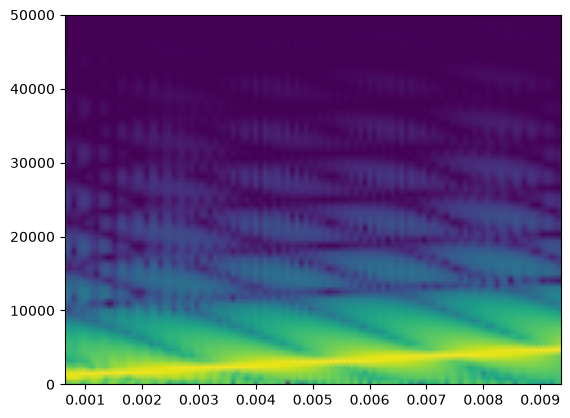

In [5]:
plt.figure()
plt.pcolormesh(tt, f, 10*np.log10(Sxx + 1e-12), shading='gouraud')
plt.show()

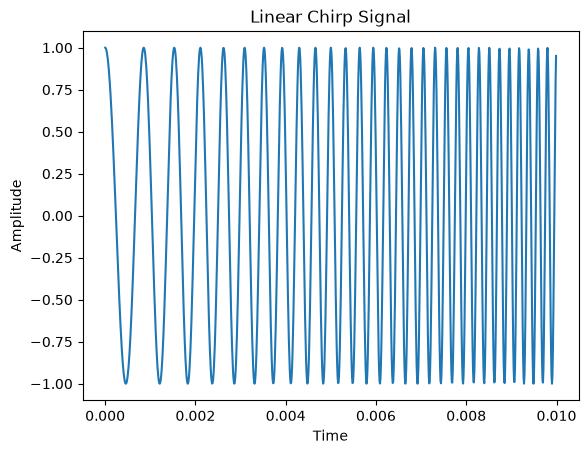

In [6]:
plt.figure()
plt.plot(t, x, '-')
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Linear Chirp Signal")
plt.show()

In [3]:
Fs = 250e3
f0 = 30e3

t = np.arange(0, 0.02, 1/Fs)
x = np.exp(1j * 2*np.pi * f0 * t)

/tmp/ipykernel_22733/2230936886.py:1: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Sxx = spectrogram(x, Fs, nperseg=1024, noverlap=240)


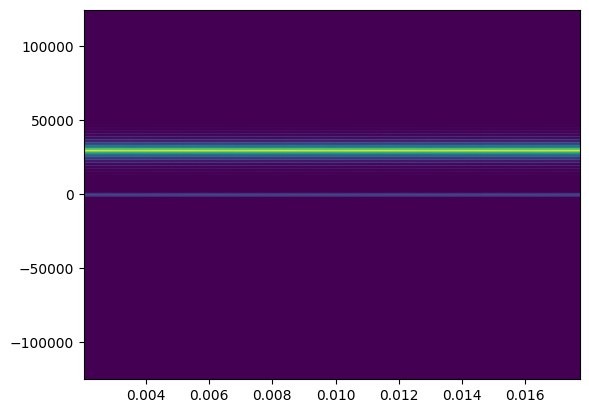

In [11]:
f, t, Sxx = spectrogram(x, Fs, nperseg=1024, noverlap=240)

plt.figure()
plt.pcolormesh(t, np.fft.fftshift(f), 10*np.log10(np.fft.fftshift(Sxx, axes=0)+1e-12), shading='gouraud')
plt.show()

In [30]:
from wirelessComm import LoRa
import numpy as np
import matplotlib.pyplot as plt

In [32]:
SF = 8
noChirps = 2**SF
BW = int(125e3)
sampRate = BW * 1
initialfreq = -BW / 2
symDuration = 2**SF / BW
chirpRate = BW / symDuration
sampPerSym = sampRate * symDuration

lora = LoRa(SF, BW, sampRate, initialfreq)
SNR = 10
msg_len = SF

In [33]:
msg = np.random.randint(0, 2, msg_len)
refChirp = lora.genRefChirp()
symbol = lora.bin2dec(msg)
sigTx = lora.genSymChirp(refChirp, symbol)

In [41]:
# multitap channel: with real attenuation constant
atten = np.random.uniform(0.1, 0.99)
# -- complex channel gain
# atten = (np.random.rayleigh(scale=1)*np.exp(1j * np.random.uniform(0, 2*np.pi)))
pathDelay = 10
zero = np.zeros(pathDelay-1)
ch = np.concatenate((1, zero, atten), axis=None)
print(f"path delay: {pathDelay}")
sigRx = np.convolve(sigTx, ch)
print(f"Symbol Transmitted: {symbol}\n Attentuation Const: {atten}")
print(f"Gain: {abs(atten)}, Angle: {np.angle(atten)}")
print(f"Len of Tx Signal: {len(sigTx)}, \n length of received signal: {len(sigRx)}")

path delay: 10
Symbol Transmitted: 137
 Attentuation Const: 0.20615246880137073
Gain: 0.20615246880137073, Angle: 0.0
Len of Tx Signal: 256, 
 length of received signal: 266


Decoded Symbol: 137
[137, 127, 138]


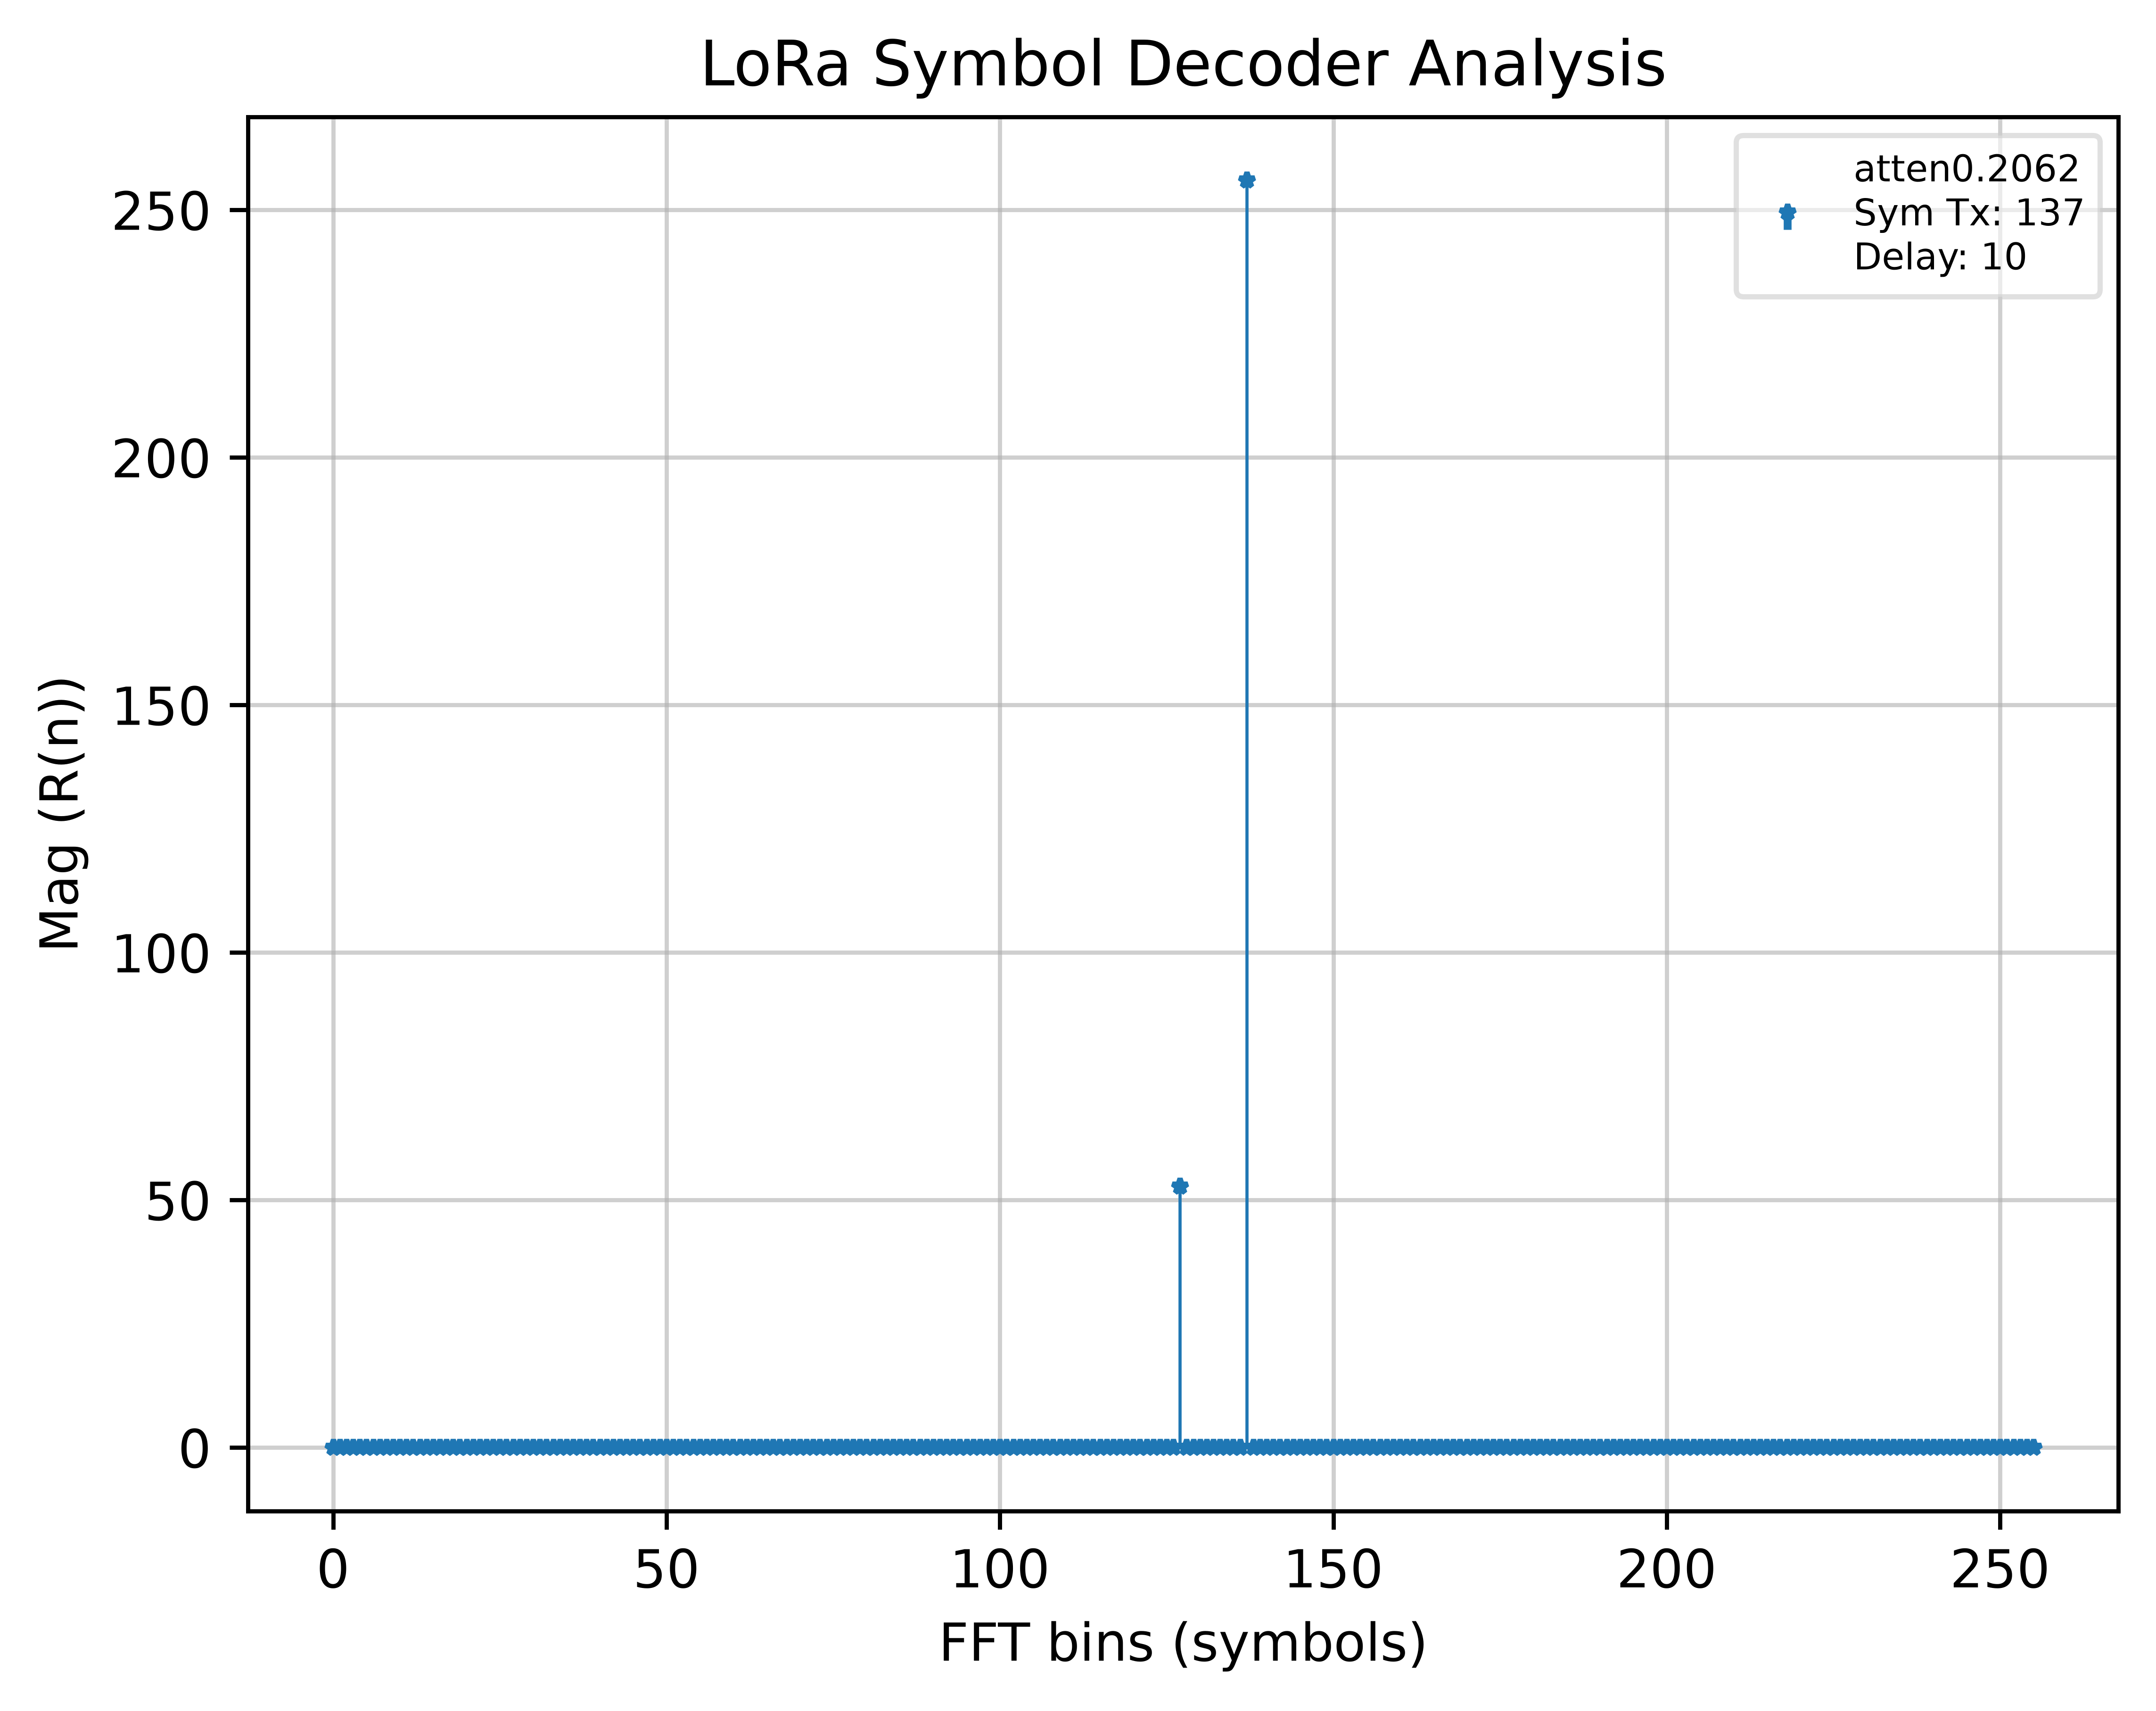

In [43]:
# dechirped = sigRx[:noChirps] * np.conjugate(refChirp)
sig1 = sigRx[:noChirps]
zeroVec = np.zeros(noChirps - len(sigRx[noChirps:]))
sig2 = np.concatenate((sigRx[noChirps:], zeroVec), axis=None)
dechirped = (sig1 + sig2) * np.conjugate(refChirp)
dechirpFFT = np.fft.fft(dechirped)
print(f"Decoded Symbol: {np.argmax(abs(dechirpFFT))}")
indices = sorted( range(len(dechirpFFT)), key=lambda i: abs(dechirpFFT[i]), reverse=True )[:3]
print(indices)
f = np.fft.fftfreq(int(sampPerSym), sampRate)

plt.figure(1, dpi=800)
markerline, stemlines, baseline = plt.stem(abs(dechirpFFT), basefmt=" ", markerfmt="*", label=f"atten{np.round(atten, 4)}\nSym Tx: {symbol}\nDelay: {pathDelay}")
plt.setp(stemlines, linewidth=0.6)
plt.setp(markerline, markersize=3)
plt.legend(loc='upper right', fontsize=7, framealpha=0.6)
plt.grid(True, alpha=0.6)
plt.xlabel("FFT bins (symbols)")
plt.ylabel("Mag (R(n))")
plt.title("LoRa Symbol Decoder Analysis")
plt.savefig(f"results/singleTap{pathDelay}.jpeg")

# Lagrange Implementation for Fractional Delay

In [34]:
def lagrange_fractional_delay(mu, order=3):
    """
    Largrange fractional delay FIR filter
    mu: fractional delay  0 <= mu < 1
    order: Interpolation order 
        - How does interpolation order effects the reconstruction of filter
    """
    h = np.ones(order+1)
    for k in range(order+1):
        for m in range(order+1):
            if m!= k:
                h[k] *= (mu - m)/(k - m)
    return h

In [35]:
def make_channel_lagrange(delays, gains, order=7):
    """
    Construction of multipath channel impulse response 
    using lagrange fractional-delay interpolation
    """
    delays = np.asarray(delays)
    gains = np.asarray(gains)
    max_delay = int(np.floor(np.max(delays))) + order
    h = np.zeros(max_delay+1, dtype=complex)

    for d, a in zip(delays, gains):
        D = int(np.floor(d))
        mu = d - D
    
        hf = lagrange_fractional_delay(mu, order)

        h[D: D+order+1] += a * hf
    return h

In [36]:
delay = np.round(np.random.uniform(0.1, 20), 4)
chGain = np.round(np.random.uniform(0.1, 0.4), 4)

delays = np.array([0, delay])
gains = np.array([1, chGain])
h = make_channel_lagrange(delays, gains)
print(f"Channel Length:{len(h)}")
sigRx = np.convolve(sigTx, h)
print(f"Delay: {delay}, chGain: {chGain}")

Channel Length:23
Delay: 15.1912, chGain: 0.1999


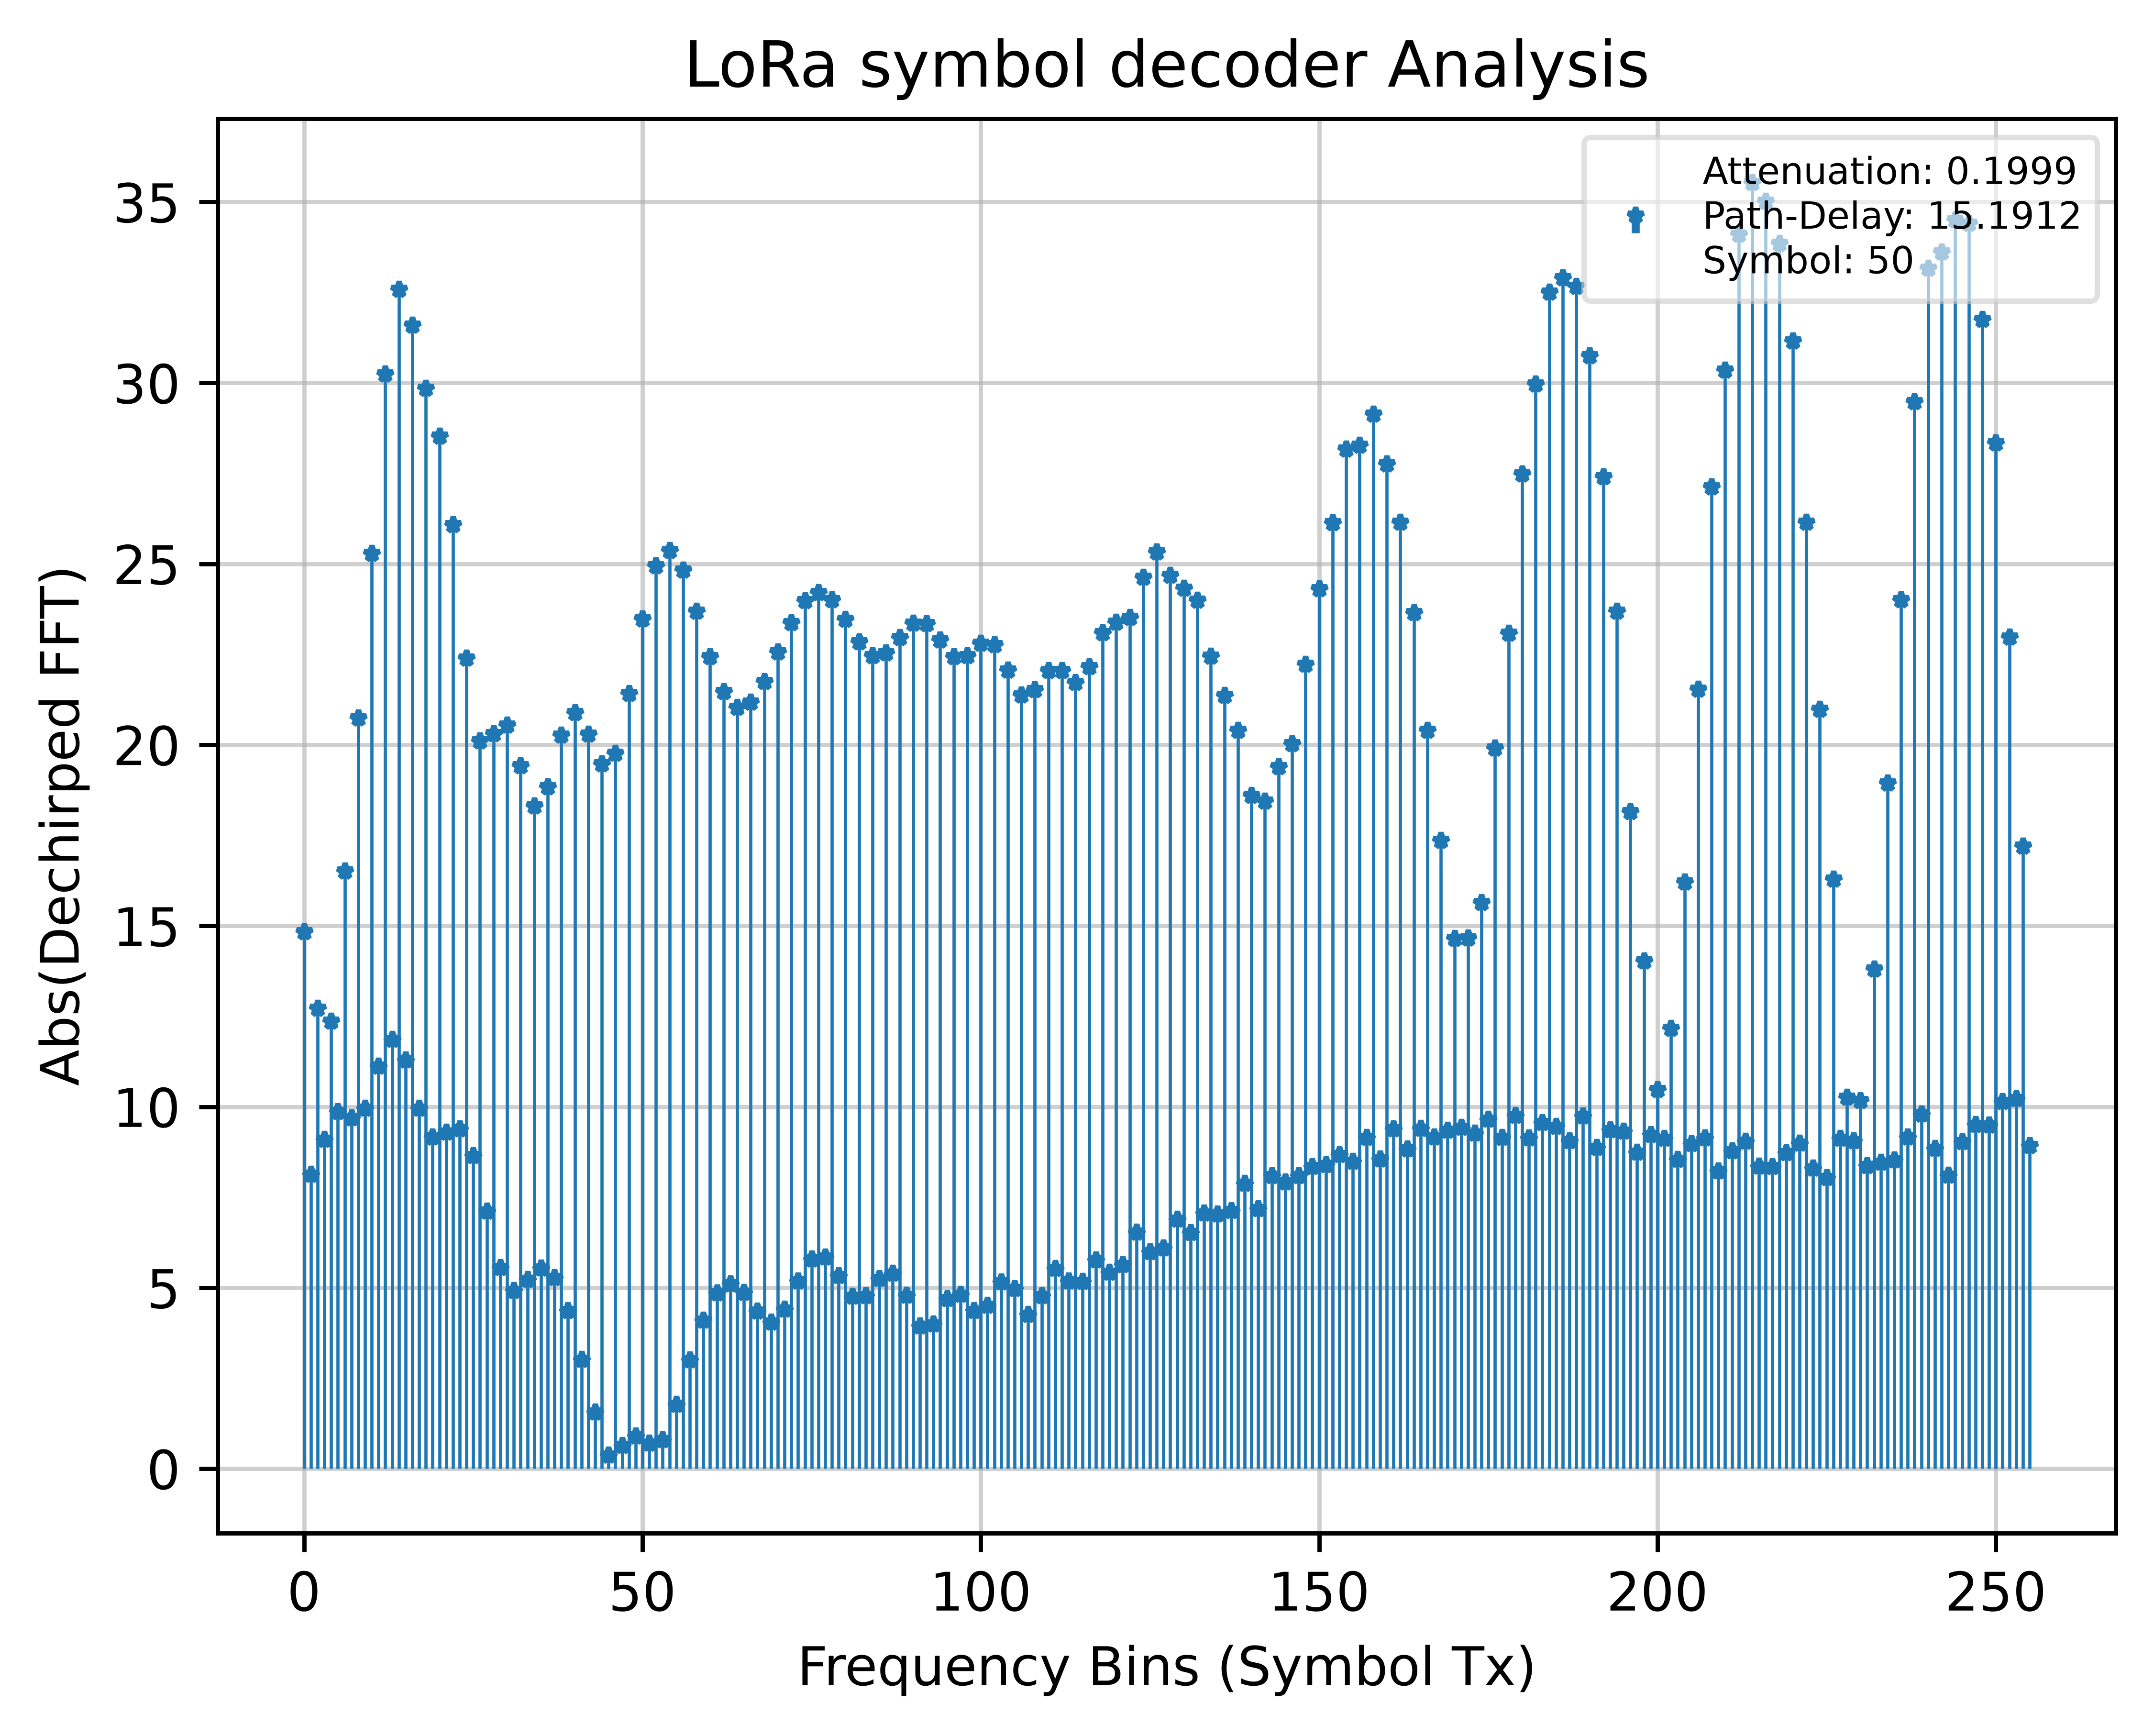

In [37]:
dechirped = sigRx[:noChirps] * refChirp
dechirpFFT = np.fft.fft(dechirped)

plt.figure(1, dpi=800)
markerline, stemline, baseline = plt.stem(abs(dechirpFFT), basefmt=" ", markerfmt="*", label=f"Attenuation: {chGain}\nPath-Delay: {delay}\nSymbol: {symbol}")
plt.setp(markerline, markersize=3)
plt.setp(stemline, linewidth=0.6)
plt.xlabel("Frequency Bins (Symbol Tx)")
plt.ylabel("Abs(Dechirped FFT)")
plt.title("LoRa symbol decoder Analysis")
plt.grid(True, alpha=0.6)
plt.legend(loc='upper right', framealpha=0.6, fontsize=7)
# plt.savefig(f"results/singleTapDelay{delay}.jpeg")
plt.show()